In [ ]:
#Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import the necessary packages
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib import gridspec

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder


from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef


from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.datasets import load_digits
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight


from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy


import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset from the csv file using pandas
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CSE422_Project/healthcare-dataset-stroke-data.csv")



In [ ]:
# Take a peek at the data
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [ ]:
# Print the shape of the data
print(data.shape)
print(data.describe().round())

(5110, 12)
            id     age  hypertension  heart_disease  avg_glucose_level  \
count   5110.0  5110.0        5110.0         5110.0             5110.0   
mean   36518.0    43.0           0.0            0.0              106.0   
std    21162.0    23.0           0.0            0.0               45.0   
min       67.0     0.0           0.0            0.0               55.0   
25%    17741.0    25.0           0.0            0.0               77.0   
50%    36932.0    45.0           0.0            0.0               92.0   
75%    54682.0    61.0           0.0            0.0              114.0   
max    72940.0    82.0           1.0            1.0              272.0   

          bmi  stroke  
count  4909.0  5110.0  
mean     29.0     0.0  
std       8.0     0.0  
min      10.0     0.0  
25%      24.0     0.0  
50%      28.0     0.0  
75%      33.0     0.0  
max      98.0     1.0  


In [ ]:
# Determine number of stroke and non_stroke cases in dataset
stroke= data[data['stroke'] == 1]
non_stroke = data[data['stroke'] == 0]
outlier = float(len(stroke))/float(len(non_stroke))
print('Brief of all cases')
print()
print('Outlier cases: {} '.format(outlier))
print('stroke Cases: {}'.format(len(data[data['stroke'] == 1])))
print('non_stroke cases: {}'.format(len(data[data['stroke'] == 0])))

Brief of all cases

Outlier cases: 0.051224027977782347 
stroke Cases: 249
non_stroke cases: 4861


In [ ]:
print('Details of non_stroke cases')
print()
print ('non_stroke cases % ',round(data['stroke'].value_counts()[0]/len(data)*100,2))
print (round(data.age[data.stroke == 0].describe(),2))
print()
print('Details of stroke cases')
print()
print ('stroke cases %    ',round(data['stroke'].value_counts()[1]/len(data)*100,2))
print (round(data.age[data.stroke == 1].describe(),2))

Details of non_stroke cases

non_stroke cases %  95.13
count    4861.00
mean       41.97
std        22.29
min         0.08
25%        24.00
50%        43.00
75%        59.00
max        82.00
Name: age, dtype: float64

Details of stroke cases

stroke cases %     4.87
count    249.00
mean      67.73
std       12.73
min        1.32
25%       59.00
50%       71.00
75%       78.00
max       82.00
Name: age, dtype: float64


non_stroke %  95.13
stroke %     4.87


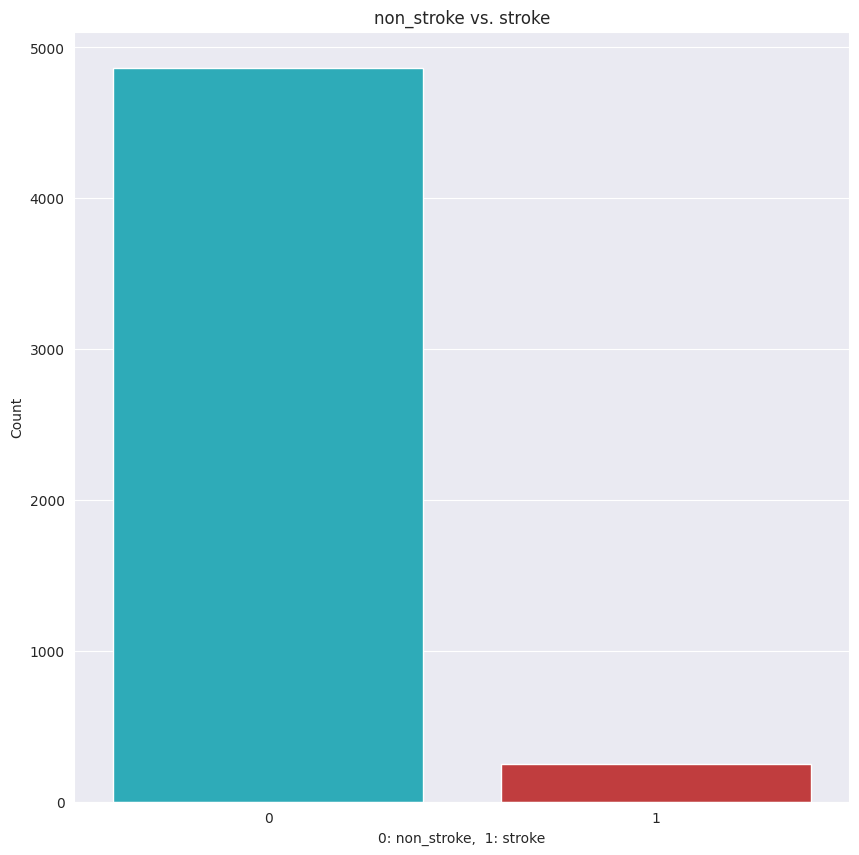

In [ ]:
plt.figure(figsize=(10,10))
sns.set_style('darkgrid')
sns.barplot(x=data['stroke'].value_counts().index,y=data['stroke'].value_counts(), palette=["C9", "C3"])
plt.title('non_stroke vs. stroke')
plt.ylabel('Count')
plt.xlabel('0: non_stroke,  1: stroke')
print ('non_stroke % ',round(data['stroke'].value_counts()[0]/len(data)*100,2))
print ('stroke %    ',round(data['stroke'].value_counts()[1]/len(data)*100,2));

# Dataset preprocessing

In [ ]:
#Check for Null values
print("Null values in the dataset :")
print(data.isnull().sum())

total_nulls = data.isnull().sum().sum()
print("\nTotal null values in the dataset:", total_nulls)


Null values in the dataset :
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Total null values in the dataset: 201


In [ ]:
# Remove rows with any null values
data = data.dropna()

print("Null values after removal:")
print(data.isnull().sum())


Null values after removal:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [ ]:
#  Check for categorical values
categorical_columns = data.select_dtypes(include=['object', 'category']).columns

if len(categorical_columns) == 0:
    print("Categorical columns in the dataset: 0")
else:
    print("Categorical columns in the dataset:")
    print(categorical_columns)


Categorical columns in the dataset:
Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


In [ ]:
data_encoded = data.copy()
le = LabelEncoder()

for col in categorical_columns:
    unique_values = data_encoded[col].nunique()


    if unique_values == 2:
        print(f"Label Encoding applied to '{col}' (binary category)")
        data_encoded[col] = le.fit_transform(data_encoded[col])
    else:
        print(f"One-Hot Encoding applied to '{col}' (more than 2 categories)")

        one_hot = pd.get_dummies(data_encoded[col], prefix=col)
        data_encoded = pd.concat([data_encoded.drop(col, axis=1), one_hot], axis=1)


One-Hot Encoding applied to 'gender' (more than 2 categories)
Label Encoding applied to 'ever_married' (binary category)
One-Hot Encoding applied to 'work_type' (more than 2 categories)
Label Encoding applied to 'Residence_type' (binary category)
One-Hot Encoding applied to 'smoking_status' (more than 2 categories)


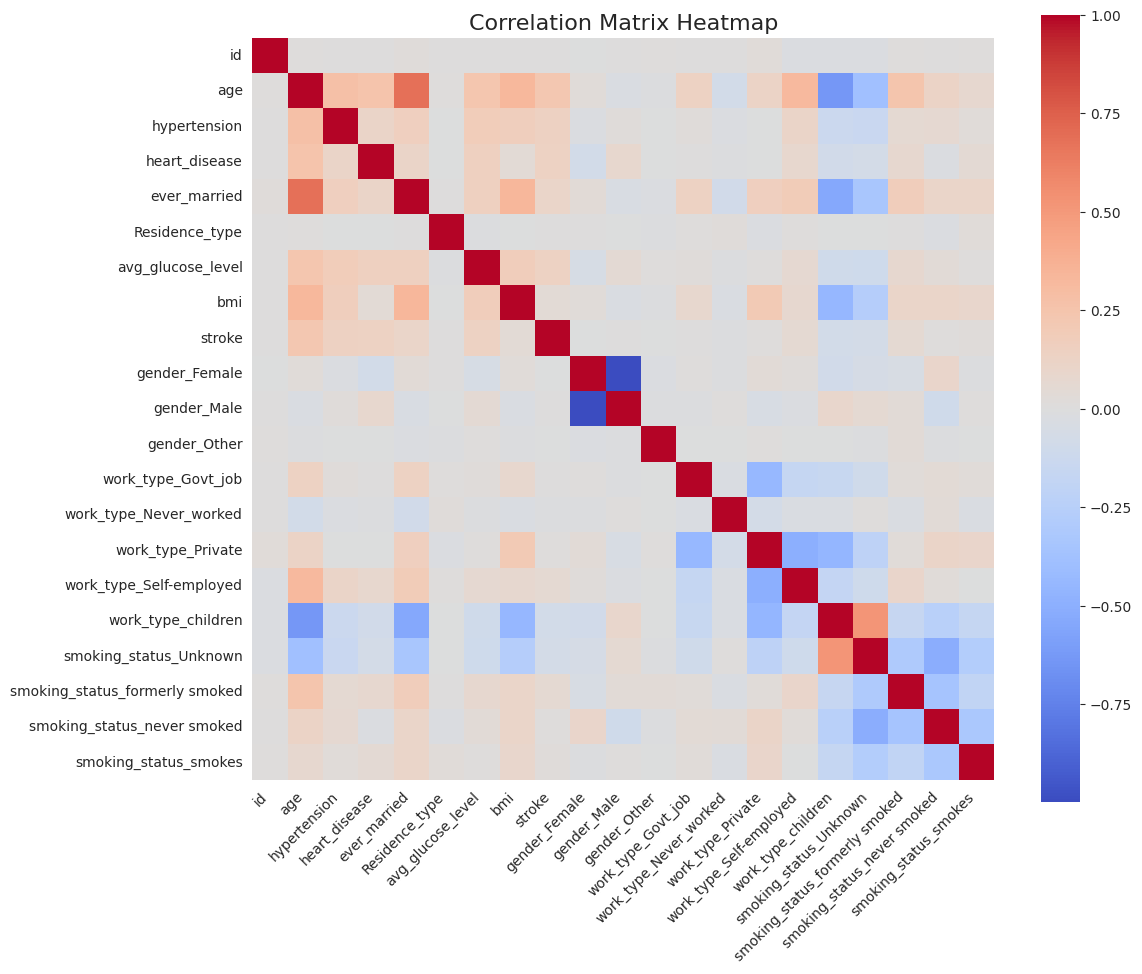

In [ ]:
corr_matrix = data_encoded.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', square=True, cbar=True, annot=False)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()

data_encoded[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

print("\nNormalized numerical columns:")
print(data_encoded[numeric_cols].head())



Normalized numerical columns:
        age  avg_glucose_level       bmi
0  1.070138           2.777698  0.981345
2  1.646563           0.013842  0.459269
3  0.272012           1.484132  0.701207
4  1.602222           1.549193 -0.623083
5  1.690903           1.821368  0.013595


In [ ]:
dropping_col = []

for col, val in corr_matrix['stroke'].items():
    if (abs(val) < 0.05):
        dropping_col.append(col)

for i in dropping_col:
    data_encoded.drop(i, axis=1, inplace=True)

# dropping_col.remove('id')
# data_encoded.drop(dropping_col, axis = 1, inplace = True)

data_encoded.head(10)

,age,hypertension,heart_disease,ever_married,avg_glucose_level,stroke,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked
0,1.070138,0,1,1,2.777698,1,False,False,False,True
2,1.646563,0,1,1,0.013842,1,False,False,False,False
3,0.272012,0,0,1,1.484132,1,False,False,False,False
4,1.602222,1,0,1,1.549193,1,True,False,False,False
5,1.690903,0,0,1,1.821368,1,False,False,False,True
6,1.380520,1,1,1,-0.792780,1,False,False,False,False
7,1.158819,0,0,0,-0.245727,1,False,False,False,False
9,1.557882,0,0,1,-1.052124,1,False,False,True,False
10,1.690903,1,0,1,-0.560001,1,False,False,False,False
11,0.804096,0,1,1,0.341173,1,False,False,False,False


In [ ]:
y = data_encoded['stroke']
X = data_encoded.drop('stroke', axis=1)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=42, stratify=y )

print("Shape of training set:", X_train.shape)
print("Shape of testing set:", X_test.shape)

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True).round(4) * 100)


Shape of training set: (3436, 9)
Shape of testing set: (1473, 9)

Class distribution in training set:
stroke
0    95.75
1     4.25
Name: proportion, dtype: float64

Class distribution in testing set:
stroke
0    95.72
1     4.28
Name: proportion, dtype: float64


In [ ]:
#@title Naive Bayes

class_weights = y_train.value_counts(normalize=True).sort_index().values

nb_model = GaussianNB(priors=class_weights)
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

Accuracy: 0.428377460964019
Precision: 0.06770255271920089
Recall: 0.9682539682539683
F1 Score: 0.12655601659751037
Matthews Corr Coef: 0.15465235091295187
AUC Score: 0.78849487785658


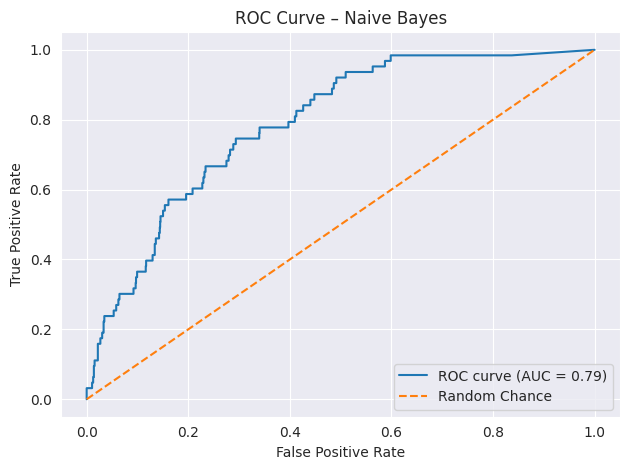

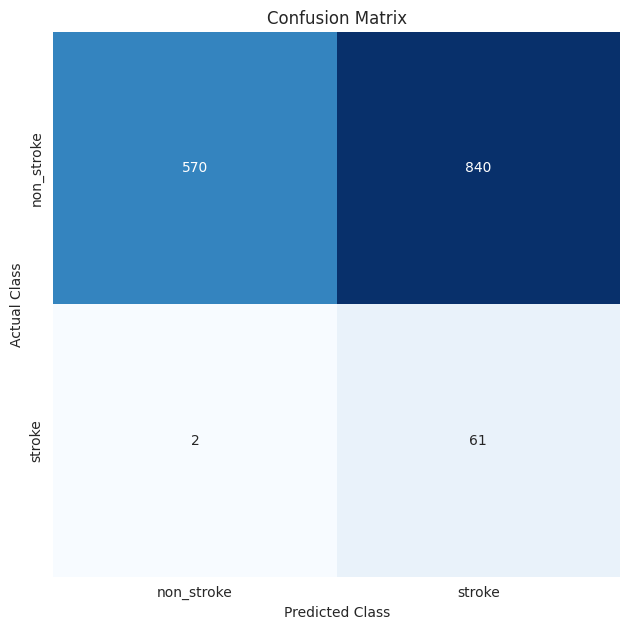

In [ ]:
#@title Naive Bayes Evaluataion

print("Accuracy:",             accuracy_score(y_test, y_pred_nb))
print("Precision:",            precision_score(y_test, y_pred_nb))
print("Recall:",               recall_score(y_test, y_pred_nb))
print("F1 Score:",             f1_score(y_test, y_pred_nb))
print("Matthews Corr Coef:",   matthews_corrcoef(y_test, y_pred_nb))
print("AUC Score:",            roc_auc_score(y_test, y_prob_nb))



fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Naive Bayes')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

LABELS = ['non_stroke', 'stroke']

print()

conf_mtx = confusion_matrix(y_test, y_pred_nb)


plt.figure(figsize=(6.4, 6.4))
sns.heatmap(
    conf_mtx,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=False)
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


In [ ]:
#@title Logistic Regression

log_model = LogisticRegression(max_iter= 5000, class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]


Accuracy: 0.7610319076714189
Precision: 0.11671087533156499
Recall: 0.6984126984126984
F1 Score: 0.2
Matthews Corr Coef: 0.2143254472832037
AUC Score: 0.823370482944951


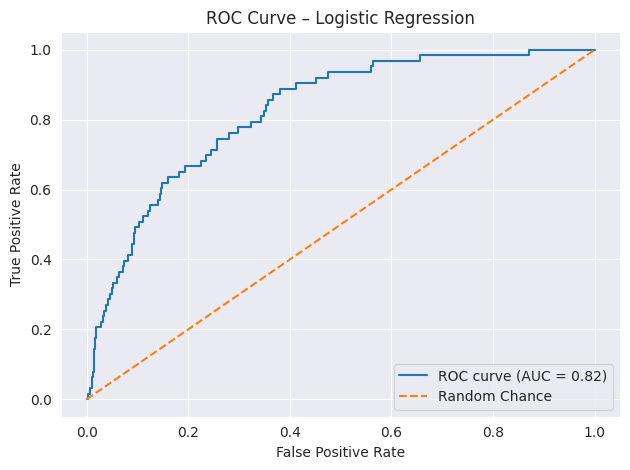

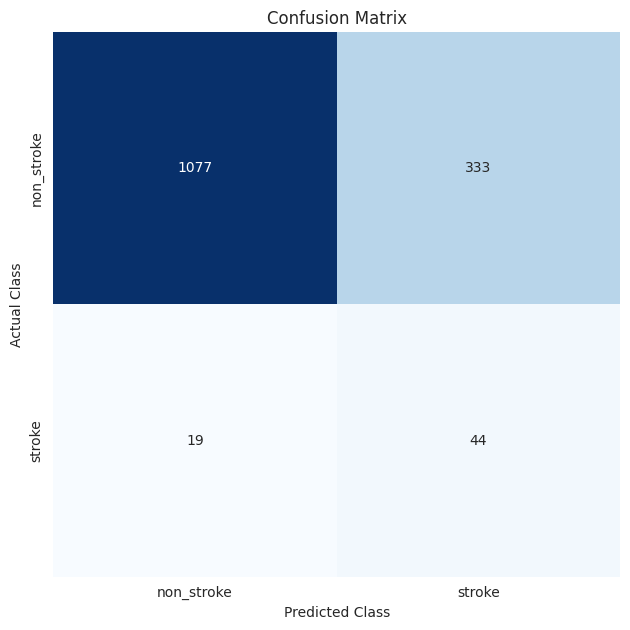

In [ ]:
#@title Logistic Regression Evaluataion

print("Accuracy:",             accuracy_score(y_test, y_pred_log))
print("Precision:",            precision_score(y_test, y_pred_log))
print("Recall:",               recall_score(y_test, y_pred_log))
print("F1 Score:",             f1_score(y_test, y_pred_log))
print("Matthews Corr Coef:",   matthews_corrcoef(y_test, y_pred_log))
print("AUC Score:",            roc_auc_score(y_test, y_prob_log))



fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

LABELS = ['non_stroke', 'stroke']

print()

conf_mtx = confusion_matrix(y_test, y_pred_log)


plt.figure(figsize=(6.4, 6.4))
sns.heatmap(
    conf_mtx,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=False)
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


In [ ]:
#@title Neural Network


class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))


ann_model = Sequential([
    Flatten(input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation="sigmoid")
])

ann_model.compile(optimizer=Adam(0.001),
                            loss='binary_crossentropy',
                            metrics=['accuracy'])

history = ann_model.fit(X_train, y_train, epochs=100, batch_size=128, class_weight=class_weights_dict)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3981 - loss: 0.6066
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7531 - loss: 0.4502
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6644 - loss: 0.4375
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6853 - loss: 0.4483
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7386 - loss: 0.4167
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7109 - loss: 0.4269
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7451 - loss: 0.3958
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7016 - loss: 0.4214
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7340 - loss: 0.4008
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7440 - loss: 0.4064
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7405 - loss: 0.3862
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8391038696537678
Precision: 0.14049586776859505
Recall: 0.5396825396825397
F1 Score: 0.22295081967213115
Matthews Corr Coef: 0.21414687507767416
AUC Score: 0.8011482607227288


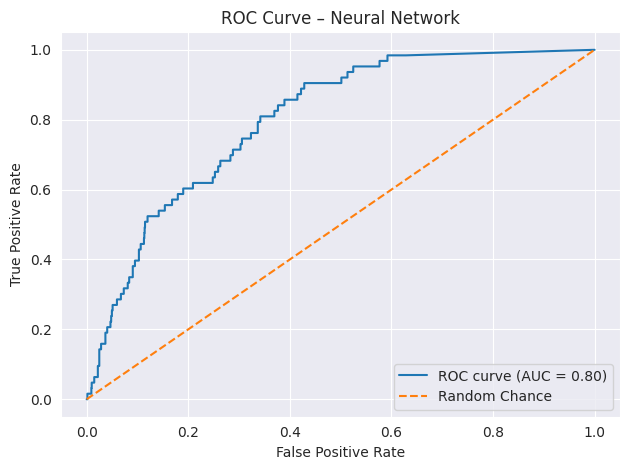

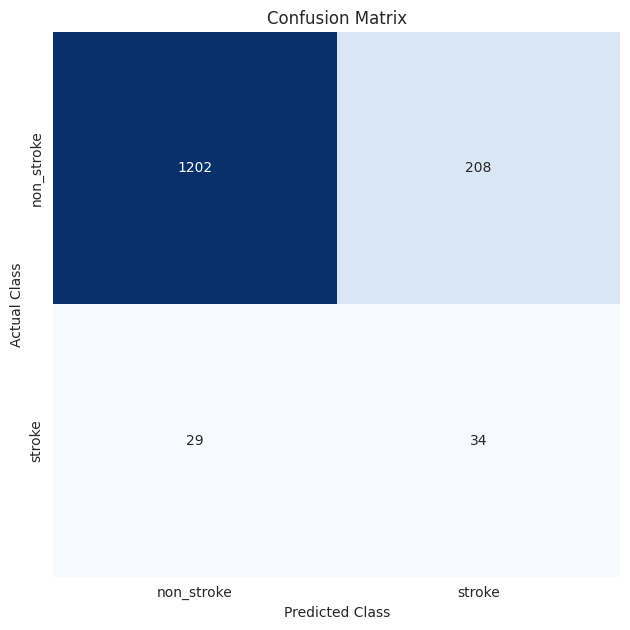

In [ ]:
#@title Neural Network Evaluation

pred = ann_model.predict(X_test)
y_pred_ann = (pred > 0.5).astype(int)
y_prob_ann = pred

print("Accuracy:",             accuracy_score(y_test, y_pred_ann))
print("Precision:",            precision_score(y_test, y_pred_ann))
print("Recall:",               recall_score(y_test, y_pred_ann))
print("F1 Score:",             f1_score(y_test, y_pred_ann))
print("Matthews Corr Coef:",   matthews_corrcoef(y_test, y_pred_ann))
print("AUC Score:",            roc_auc_score(y_test, y_prob_ann))



fpr, tpr, thresholds = roc_curve(y_test, y_prob_ann)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Neural Network')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

LABELS = ['non_stroke', 'stroke']

print()

conf_mtx = confusion_matrix(y_test, y_pred_ann)


plt.figure(figsize=(6.4, 6.4))
sns.heatmap(
    conf_mtx,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=False)
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

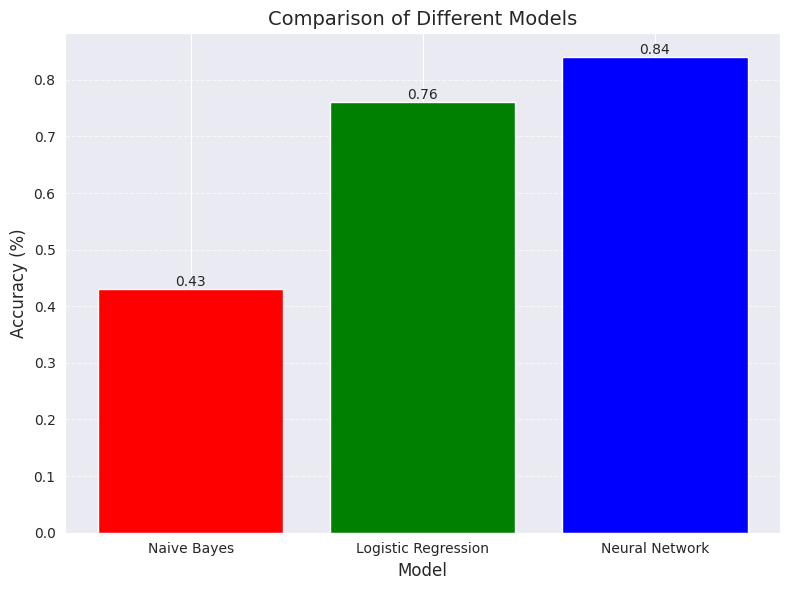

In [ ]:
#@title Accuracy Comparison between models

model = ['Naive Bayes', 'Logistic Regression', 'Neural Network']
accuracy = [round(accuracy_score(y_test, y_pred_nb), 2), round(accuracy_score(y_test, y_pred_log), 2), round(accuracy_score(y_test, y_pred_ann), 2)]

plt.figure(figsize=(8, 6))
bars = plt.bar(model, accuracy, color=['red', 'green', 'blue'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.title('Comparison of Different Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()